##### 5. Train and fine-tune a decision tree for the moons dataset by following these steps:                                                a. Use make_moons(n_samples=10000, noise=0.4) to generate a moons dataset.                                                               b. Use train_test_split() to split the dataset into a training set and a test set.                                                        c. Use grid search with cross-validation (with the help of the GridSearchCV class) to find good hyperparameter values for a DecisionTreeClassifier. Hint: try various values for max_leaf_nodes.                                                                      d. Train it on the full training set using these hyperparameters, and measure your model’s performance on the test set. You should get roughly 85% to 87% accuracy

In [13]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
X, y= make_moons(n_samples= 10000, noise= 0.4)
df= pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df["Target"]= y

In [5]:
df.sample(5)

,Feature 1,Feature 2,Target
1009,0.175798,0.452565,0
2255,-1.001324,0.456654,0
2115,0.572293,-0.571084,1
4518,-0.092827,0.003938,1
2015,0.705809,-0.183188,1


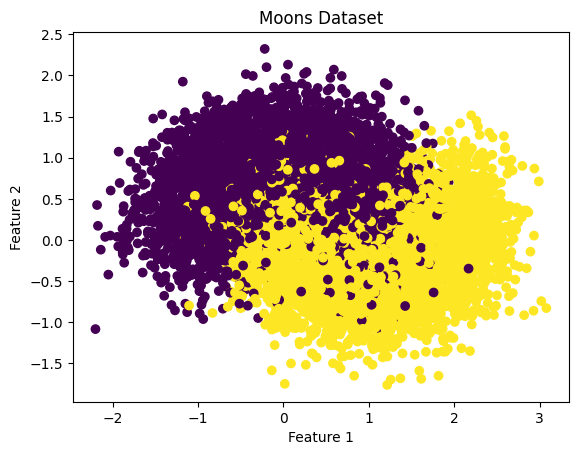

In [6]:
plt.scatter(df["Feature 1"], df["Feature 2"], c= df["Target"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [7]:
X= df.iloc[:, :-1]
y= df.iloc[:, -1]

In [8]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [9]:
param_grid={
    'max_depth': list(range(2, 15)),
    'max_leaf_nodes': list(range(2, 100)),
    'criterion':['gini', 'entropy']
}

In [10]:
model= GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy'
)

In [12]:
model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'max_leaf_nodes': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [15]:
print(model.best_estimator_)
print("Best Hyperparameters:", model.best_params_)
print("Best CV Score:", model.best_score_)

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=23, random_state=42)
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 6, 'max_leaf_nodes': 23}
Best CV Score: 0.85625


In [16]:
y_pred= model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8645


In [17]:
result= pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(result)

      Actual  Predicted
6252       0          0
4684       1          1
1731       1          1
4742       1          0
4521       0          0
...      ...        ...
6412       1          1
8285       0          1
7853       1          1
1095       1          0
6929       0          0

[2000 rows x 2 columns]


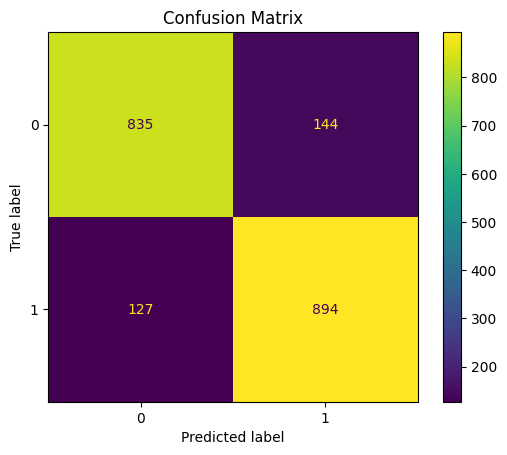

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       979
           1       0.86      0.88      0.87      1021

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



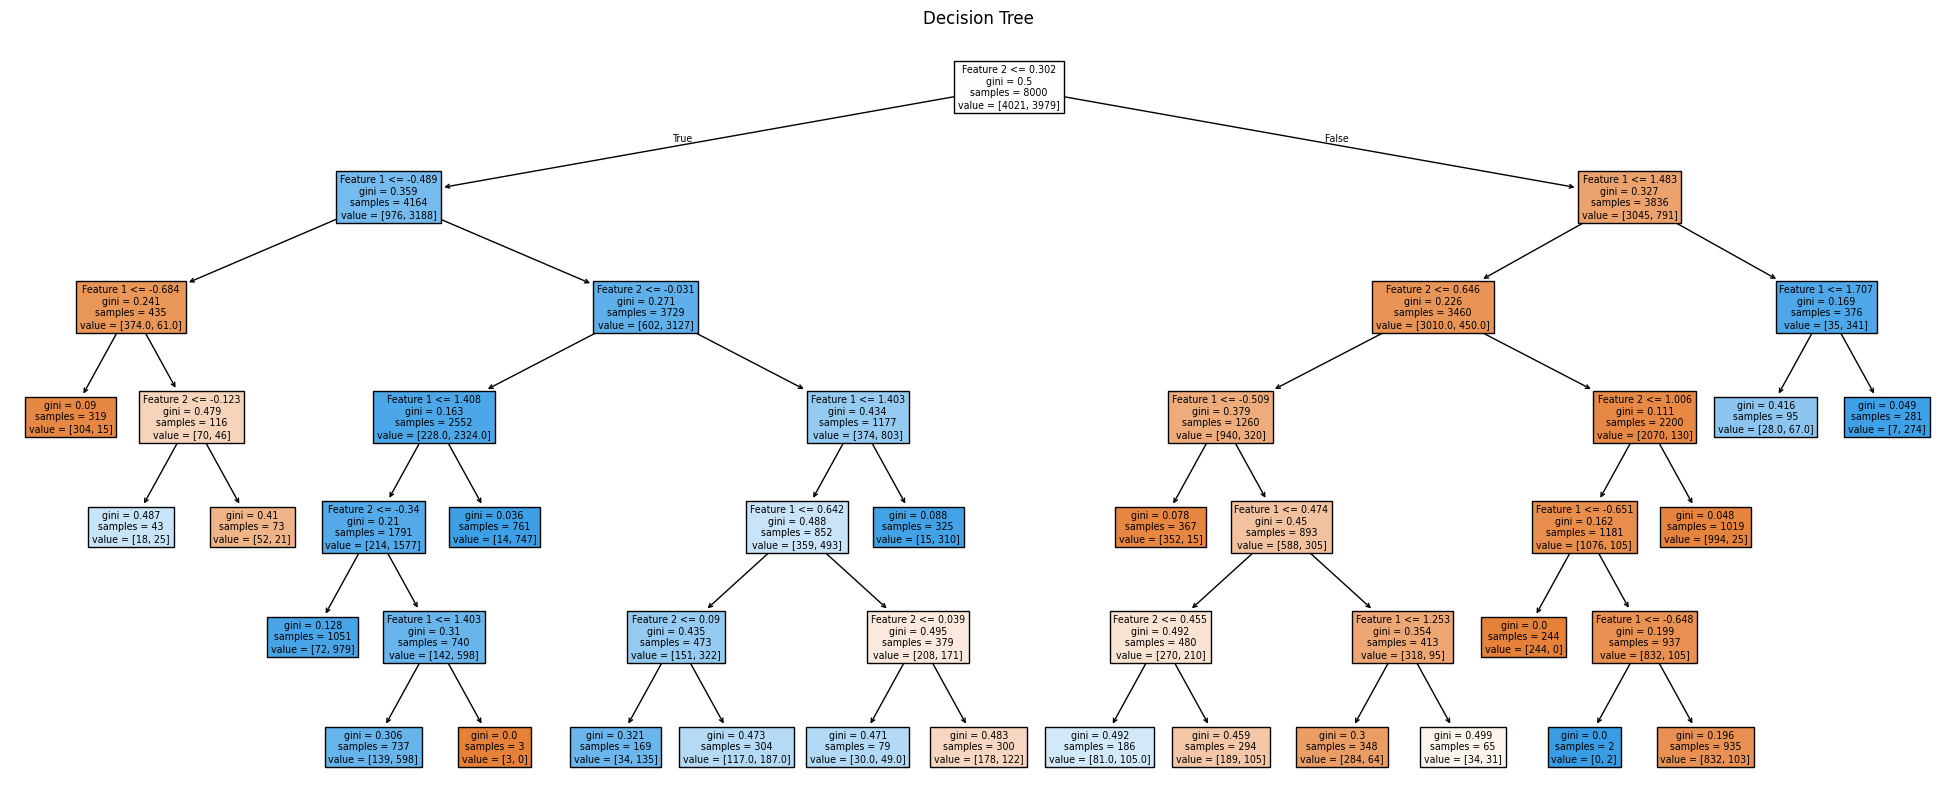

In [21]:
plt.figure(figsize= (25,10))
plot_tree(model.best_estimator_,
          feature_names= ["Feature 1", "Feature 2"],
         filled= True)
plt.title("Decision Tree")
plt.show()